In [1]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.api import qqplot

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from tqdm.notebook import tqdm
from itables import init_notebook_mode
init_notebook_mode()

In [11]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet')
panel

Loading ITables v2.6.1 from the init_notebook_mode cell... (need help?)


In [2]:
dictionary = pd.read_excel('../data/variable_dictionary.xlsx')
dictionary

Loading ITables v2.6.1 from the init_notebook_mode cell... (need help?)


In [4]:
pyg.walk(dictionary)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064ecd992de140AcskNiCWfMP1T7uw" style="height: auto">\n    <hea…

In [115]:
panel['educ'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [3]:
labels_df = dictionary[['question', 'label']].drop_duplicates()
label_dict = {}

for col, label in zip(labels_df['question'], labels_df['label']):
    label_dict[col] = label
    print(f'{col} : {label}')

id_w :  WAVE OF SURVEY=YEAR
origsm :  REPRESENTATIVE SAMPLE
region :  REGION--COVER.1
psu :  PRIMARY SAMPLE UNIT
status :  STATUS
adult :  RESPONDENT HAS ADULT FILE
child :  RESPONDENT HAS CHILD FILE
marst :  MARITAL STATUS
occup08 :  PROFESSIONAL GROUP BY ISCO2008
educ :  EDUCATION (DETAIL): OVER 14 YEARS
diplom :  COMPLETED EDUCATION (GROUP)
diplom_1 :  MOST LIKELY OF EDUCATION COMPLETED (GROUP)
h4_1 :  PARTICIPATED IN THE SURVEY:
h5 :  RESPONDENT GENDER--COV
h7_2 :  INTERVIEW MONTH--COV
h7_2_l :  DATE OF THE INTERVIEW QUESTIONNAIRE "MEDICINE": MONTH
born_m :  CHILD`S BORN MONTH
i1 :  BORN IN ANOTHER POPULATION CENTER?
i2 :  WHICH COUNTRY, REPUBLIC OF THE FORMER USSR WERE YOU BORN IN?
i3 :  BIRTHPLACE A CITY_TOWN_VILLAGE
i9_1 :  PLEASE, TELL THE MODERN NAME OF THE COUNTRY WHERE YOU WAS BORN IN.
i3_1 :  LIVED ELSEWHERE SINCE AGE 14?
i4 :  NATIONALITY CONSIDERS SELF
i5 :  WHAT LANGUAGE DO YOU MOSTLY PERSONALLY SPEAK AT HOME? IF YOU SPEAK SEVERAL LANG
i6 :  LANGUAGE SPOKEN IN HOME AS CH

In [117]:
for col, label in zip(labels_df['question'], labels_df['label']):
    if 'disab' in label.lower():
        print(f'{col} : {label}')

j74_2 :  PENSION FOR DISABILITY?
j163_4a :  Were there any breaks in your work activity due to temporary disability?
j163_7a :  Were there any breaks in your work activity due to caring for a disabled person
j16314a :  What were the reasons for these breaks: TEMPORARY DISABILITY
j16317a :  What were the reasons for these breaks: CARING FOR A DISABLED PERSON OF THE 1ST
j16511a :  What reasons for early retirement did you have: DISABLED PERSONS DUE TO WAR INJ
m20_7 :  ASSIGNED TO DISABILITY CLASS.?
m20_9m :  REGISTERED AS DISABLED--MONTH


In [118]:
for col, label in zip(labels_df['question'], labels_df['label']):
    if 'pension' in label.lower():
        print(f'{col} : {label}')

j73 :  RECEIVES A PENSION?
j74 :  TYPE OF PENSION RECEIVED
j74_1 :  PENSION FOR RETIREMENT?
j74_2 :  PENSION FOR DISABILITY?
j74_3 :  PENSION FOR YEARS OF SERVICE?
j74_4 :  PENSION FOR YEARS OF SERVICE?
j74_5 :  PENSION FOR MILITARY SERVICE?
j74_6 :  PENSION FOR SOCIAL SECURITY?
j74_7 :  PENSION FOR OTHER?
j73_1m :  WHEN GRANTED PENSION? MONTH?
j73_2 :  EMPLOYMENT OR STATE PENSION?
j74a :  TYPE OF PENSION RECEIVED--#1
j74b :  TYPE OF PENSION RECEIVED--#2
j74_1a :  TYPE OF PENSION RECEIVED--#1
j74_1b :  TYPE OF PENSION RECEIVED--#2
j74_1c :  TYPE OF PENSION RECEIVED--#3
j74_22 :  TRANSITION TO ANOTHER KIND OF LABOUR PENSION
j74_23 :  KIND OF LABOUR PENSION
j73_1am :  WHEN GRANTED THIS PENSION?--MONTH
j238 :  EARNINGS AS A BASE FOR CALCULATION OF PENSION?
j244 :  Have you had your pension reassessed since 2002?
j245 :  Was the reassessment made based on the information available in the Pension Fun
j362 :  SOCIAL SURCHARGE TO PENSION
j249 :  Please, tell me how satisfied are you with the 

In [119]:
# labels_df.to_excel('../data/questions_lables.xlsx', index=False)

In [120]:
# with open('../data/questions_lables.json', 'w') as f:
#     json.dump(label_dict, f)

In [121]:
panel['m20_7'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [122]:
panel['is_disabled'] = np.where(panel['m20_7'].isin(['No', 'NO ANSWER']), 0, 1)

In [123]:
panel['is_disabled'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [124]:
panel['j1'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [125]:
panel['is_employed'] = np.where(panel['j1'].isin(['You are currently working', 'You are on paid leave: maternity leave or taking care of a child under 3 years o', 'You are on another kind of paid leave']), 1, 0)

In [126]:
panel['is_employed'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [127]:
panel['is_employed_disabled'] = panel['is_employed'] * panel['is_disabled']

In [128]:
panel['is_employed_disabled'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [129]:
panel['is_employed_not_disabled'] = panel['is_employed'] * panel['is_disabled'].replace({0:1, 1:0})

In [130]:
panel['is_employed_not_disabled'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [131]:
panel['j60'].value_counts().to_frame()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [132]:
panel[panel['is_employed_not_disabled'] == 1]['j40'].mean()

15585.163529903806

In [133]:
panel[panel['is_employed_disabled'] == 1]['j40'].mean()

11638.297872340425

In [134]:
is_employed_disabled_j40 = panel[panel['is_employed_disabled'] == 1]['j60'].dropna().values
print(len(is_employed_disabled_j40))
is_employed_disabled_j40

1451


array([33600., 44000., 34000., ..., 84000., 43000., 84700.])

In [135]:
# J363
is_employed_disabled_j363 = panel[panel['is_employed_disabled'] == 1]['j363'].values
print(len(is_employed_disabled_j363))
is_employed_disabled_j363

1490


array([28000., 15500.,  4000., ..., 24000., 26000.,    nan])

In [136]:
is_employed_not_disabled_j40 = panel[panel['is_employed_not_disabled'] == 1]['j60'].dropna().values
print(len(is_employed_not_disabled_j40))
is_employed_not_disabled_j40

74826


array([44000.,  7000.,  4500., ..., 50000., 80000., 60000.])

In [137]:
earnings_is_employed_disabled = panel[(panel['is_employed_disabled'] == 1)][['year', 'age', 'h5', 'j60', 'j363']].fillna(0)
earnings_is_employed_disabled['net_job'] = earnings_is_employed_disabled['j60'] - earnings_is_employed_disabled['j363']
earnings_is_employed_disabled['net_job'] = np.where(earnings_is_employed_disabled['net_job'] < 0, 0, earnings_is_employed_disabled['net_job'])
earnings_is_employed_disabled['is_disabled'] = 1
earnings_is_employed_disabled

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [138]:
earnings_is_employed_disabled['net_job'].mean()

29149.9447852349

In [139]:
panel[panel['is_employed_not_disabled'] == 1]['j60'].mean()

37589.93705770721

In [140]:
earnings_is_employed_not_disabled = panel[(panel['is_employed_not_disabled'] == 1)][['year', 'age', 'h5', 'j60', 'j363']].fillna(0)
earnings_is_employed_not_disabled['net_job'] = earnings_is_employed_not_disabled['j60'] - earnings_is_employed_not_disabled['j363']
earnings_is_employed_not_disabled['net_job'] = np.where(earnings_is_employed_not_disabled['net_job'] < 0, 0, earnings_is_employed_not_disabled['net_job'])
earnings_is_employed_not_disabled['is_disabled'] = 0
earnings_is_employed_not_disabled

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [141]:
earnings_is_employed_not_disabled['net_job'].mean()

34462.49539442931

In [142]:
net_job_income_compare = pd.concat([
    earnings_is_employed_disabled[['year', 'net_job', 'is_disabled']],
    earnings_is_employed_not_disabled[['year', 'net_job', 'is_disabled']]
])
net_job_income_compare = net_job_income_compare[net_job_income_compare['net_job'] < 1_000_000]
net_job_income_compare

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


<Axes: xlabel='is_disabled', ylabel='net_job'>

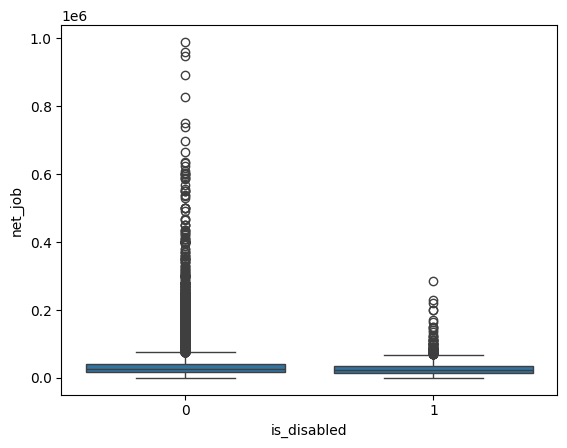

In [143]:
sns.boxplot(data=net_job_income_compare, y='net_job', x='is_disabled')

In [144]:
mod = smf.ols('net_job ~ is_disabled', net_job_income_compare).fit()
print(mod.summary2())

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.001       
Dependent Variable: net_job          AIC:                1860463.3074
Date:               2026-04-07 15:18 BIC:                1860481.8595
No. Observations:   78907            Log-Likelihood:     -9.3023e+05 
Df Model:           1                F-statistic:        57.57       
Df Residuals:       78905            Prob (F-statistic): 3.29e-14    
R-squared:          0.001            Scale:              1.0169e+09  
---------------------------------------------------------------------
              Coef.    Std.Err.    t     P>|t|    [0.025     0.975]  
---------------------------------------------------------------------
Intercept   33870.2352 114.6080 295.5312 0.0000 33645.6042 34094.8661
is_disabled -6332.6560 834.5861  -7.5878 0.0000 -7968.4398 -4696.8722
---------------------------------------------------------------------
Omnibus:             95959.770     Durb

<Figure size 1000x600 with 0 Axes>

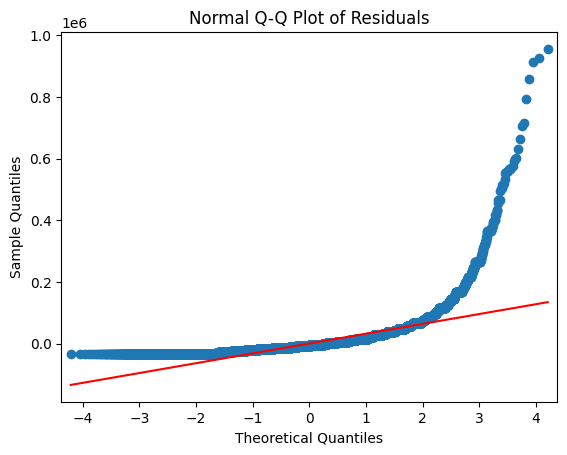

In [145]:
plt.figure(figsize=(10, 6))
qqplot(mod.resid, line='s') # 's' draws the standardized line
plt.title('Normal Q-Q Plot of Residuals')
plt.show()

In [146]:
mod = smf.ols('np.log(net_job + 1) ~ is_disabled', net_job_income_compare).fit()
print(mod.summary2())

                    Results: Ordinary least squares
Model:              OLS                 Adj. R-squared:     0.000      
Dependent Variable: np.log(net_job + 1) AIC:                355624.7272
Date:               2026-04-07 15:18    BIC:                355643.2793
No. Observations:   78907               Log-Likelihood:     -1.7781e+05
Df Model:           1                   F-statistic:        12.44      
Df Residuals:       78905               Prob (F-statistic): 0.000421   
R-squared:          0.000               Scale:              5.3068     
-------------------------------------------------------------------------
               Coef.    Std.Err.       t       P>|t|     [0.025    0.975]
-------------------------------------------------------------------------
Intercept      9.7387     0.0083   1176.2733   0.0000    9.7224    9.7549
is_disabled   -0.2126     0.0603     -3.5266   0.0004   -0.3308   -0.0945
-----------------------------------------------------------------------
Om

In [148]:
series = net_job_income_compare.set_index('year')
series

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [149]:
series_pl = (
    pl.from_pandas(series.reset_index())
        .group_by(['year', 'is_disabled']).agg(pl.col('net_job').mean())
    .with_columns(
        pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y")
    )
)
series_pl

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [150]:
alt.data_transformers.enable("vegafusion")
series_pl.plot.line(x='year', y='net_job', color='is_disabled')

alt.Chart(...)

In [100]:
for col, label in zip(labels_df['question'], labels_df['label']):
    if 'pand' in label.lower():
        print(f'{col} : {label}')

j400_5 :  TAKE THESE COURSES--TO EXPAND YOUR HORIZONS
j721525 :  CONT. EDUC.--EXPAND HORIZ.


In [6]:
for col, label in zip(labels_df['question'], labels_df['label']):
    if 'chron' in label.lower():
        print(f'{col} : {label}')

l131_4 :  FOR YOU, IS CHARACTERIZED BY CHRONIC INSOMNIA?
m20_61 :  CHRONIC HEART DISEASE?
m20_61c :  CHRONIC HEART DISEASE--CAUSE
m20_62 :  CHRONIC LUNG DISEASE?
m20_62c :  CHRONIC LUNG DISEASE--CAUSE
m20_63 :  CHRONIC LIVER DISEASE?
m20_63c :  CHRONIC LIVER DISEASE--CAUSE
m20_64 :  CHRONIC KIDNEY DISEASE?
m20_64c :  CHRONIC KIDNEY DISEASE--CAUSE
m20_65 :  CHRONIC STOMACH DISEASE?
m20_65c :  CHRONIC STOMACH DISEASE--CAUSE
m20_66 :  CHRONIC SPINAL DISEASE?
m20_66c :  CHRONIC SPINAL DISEASE--CAUSE
m20_67 :  OTHER CHRONIC DISEASE?
m20_67c :  OTHER CHRONIC DISEASE--CAUSE
m91 :  FAMILY MEMBER CHRONICALLY ILL?


In [15]:
panel['m20_62'].value_counts()

shape: (3, 2)
┌────────┬────────┐
│ m20_62 ┆ count  │
│ ---    ┆ ---    │
│ str    ┆ u32    │
╞════════╪════════╡
│ null   ┆ 741    │
│ No     ┆ 167740 │
│ Yes    ┆ 10695  │
└────────┴────────┘


In [13]:
panel['m20_612'].value_counts()

Loading ITables v2.6.1 from the init_notebook_mode cell... (need help?)


In [23]:
health_variables = [
    'm20_61', 'm20_62',  'm20_63', 'm20_64',  'm20_65', 'm20_66',  'm20_67',
    'm20_612', 'm20_613', 'm20_615', 'm20_8'
]

for var in health_variables:
    tmp = panel[var].value_counts()
    tmp = tmp.with_columns(
        prct = pl.col('count') / pl.col('count').sum() * 100
    )
    print(label_dict[var])
    print(tmp)

 CHRONIC HEART DISEASE?
shape: (3, 3)
┌────────┬────────┬───────────┐
│ m20_61 ┆ count  ┆ prct      │
│ ---    ┆ ---    ┆ ---       │
│ str    ┆ u32    ┆ f64       │
╞════════╪════════╪═══════════╡
│ null   ┆ 968    ┆ 0.540251  │
│ Yes    ┆ 19806  ┆ 11.053936 │
│ No     ┆ 158402 ┆ 88.405813 │
└────────┴────────┴───────────┘
 CHRONIC LUNG DISEASE?
shape: (3, 3)
┌────────┬────────┬───────────┐
│ m20_62 ┆ count  ┆ prct      │
│ ---    ┆ ---    ┆ ---       │
│ str    ┆ u32    ┆ f64       │
╞════════╪════════╪═══════════╡
│ null   ┆ 741    ┆ 0.41356   │
│ Yes    ┆ 10695  ┆ 5.968991  │
│ No     ┆ 167740 ┆ 93.617449 │
└────────┴────────┴───────────┘
 CHRONIC LIVER DISEASE?
shape: (3, 3)
┌────────┬────────┬───────────┐
│ m20_63 ┆ count  ┆ prct      │
│ ---    ┆ ---    ┆ ---       │
│ str    ┆ u32    ┆ f64       │
╞════════╪════════╪═══════════╡
│ Yes    ┆ 9437   ┆ 5.266888  │
│ null   ┆ 986    ┆ 0.550297  │
│ No     ┆ 168753 ┆ 94.182815 │
└────────┴────────┴───────────┘
 CHRONIC KIDNEY DISEASE

In [24]:
pl.Series(name='v', values=health_variables)

Loading ITables v2.6.1 from the init_notebook_mode cell... (need help?)
